# TSAD Dataset Analysis

This notebook provides basic exploratory data analysis (EDA) for the Tweet Sentiment Analysis Dataset (TSAD). The dataset contains tweets labeled with sentiment (positive, neutral, negative) encoded as strings, along with user and country metadata.

In [3]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

In [5]:
# Load the TSAD training dataset
train_path = "tsad/train.csv"
df = pd.read_csv(train_path, encoding="latin1")
df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


## Dataset Overview

Let's check the shape, columns, and a sample of the data.

In [6]:
# Basic info about the dataset
print(f"Shape: {df.shape}")
df.info()
df.sample(5)

Shape: (27481, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            27481 non-null  object 
 1   text              27480 non-null  object 
 2   selected_text     27480 non-null  object 
 3   sentiment         27481 non-null  object 
 4   Time of Tweet     27481 non-null  object 
 5   Age of User       27481 non-null  object 
 6   Country           27481 non-null  object 
 7   Population -2020  27481 non-null  int64  
 8   Land Area (Km²)   27481 non-null  float64
 9   Density (P/Km²)   27481 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 2.1+ MB


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
14680,7fa727590e,used is definitely cheaper... may have to get...,cheaper.,negative,noon,60-70,Chad,16425864,1259200.0,13
19162,1101ccb0b0,"Also, why are paracetamol so hard to swallow? ...",why are paracetamol so hard to swallow? Ev,negative,noon,60-70,Cyprus,1207359,9240.0,131
4996,b60b7e3175,Thanks Elaine. I`m clipping reviews for her s...,Thanks,positive,noon,60-70,Palestine State,5101414,6020.0,847
17364,c6cae646bc,"sounds cool! Liverpool`s ace, especially if y...",sounds cool!,positive,morning,0-20,Nigeria,206139589,910770.0,226
11626,255bc7ebaa,Good! luck you! I want new shoes Ly x,Good!,positive,noon,60-70,Kenya,53771296,569140.0,94


## Sentiment Distribution

Let's visualize the distribution of sentiment labels in the training data.

/tmp/ipykernel_19030/623535159.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


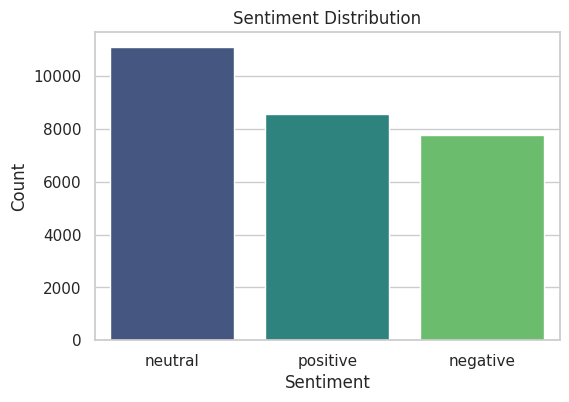

In [7]:
# Plot sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

## Tweet Length Analysis

Let's look at the distribution of tweet lengths for each sentiment.

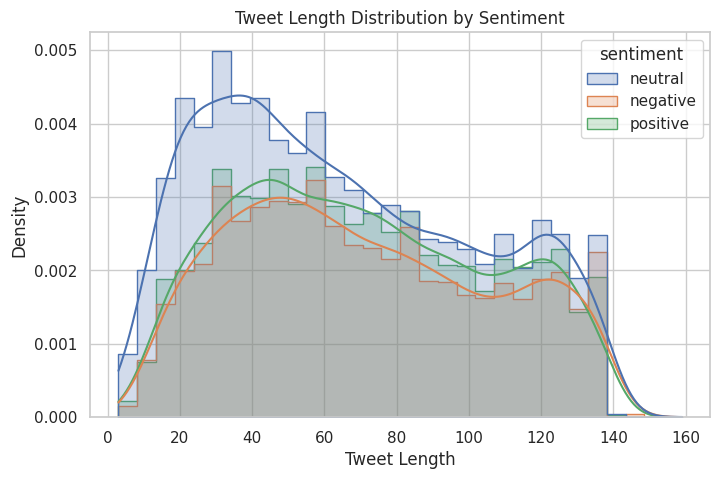

In [8]:
# Add a column for tweet length
df['tweet_length'] = df['text'].astype(str).apply(len)

# Plot tweet length distribution by sentiment
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tweet_length', hue='sentiment', bins=30, kde=True, element='step', stat='density')
plt.title('Tweet Length Distribution by Sentiment')
plt.xlabel('Tweet Length')
plt.ylabel('Density')
plt.show()

## Sentiment by Time of Tweet

Let's see if sentiment varies by the time of day the tweet was posted.

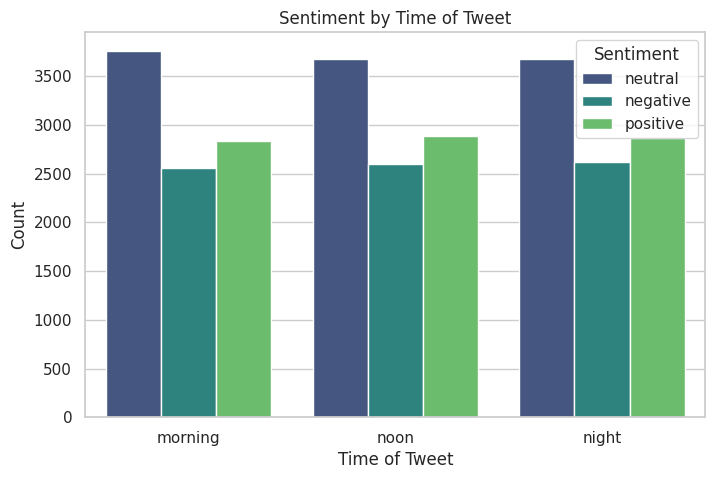

In [9]:
# Sentiment counts by time of tweet
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Time of Tweet', hue='sentiment', palette='viridis')
plt.title('Sentiment by Time of Tweet')
plt.xlabel('Time of Tweet')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.show()

## Sentiment by Age Group

Let's analyze sentiment distribution across different user age groups.

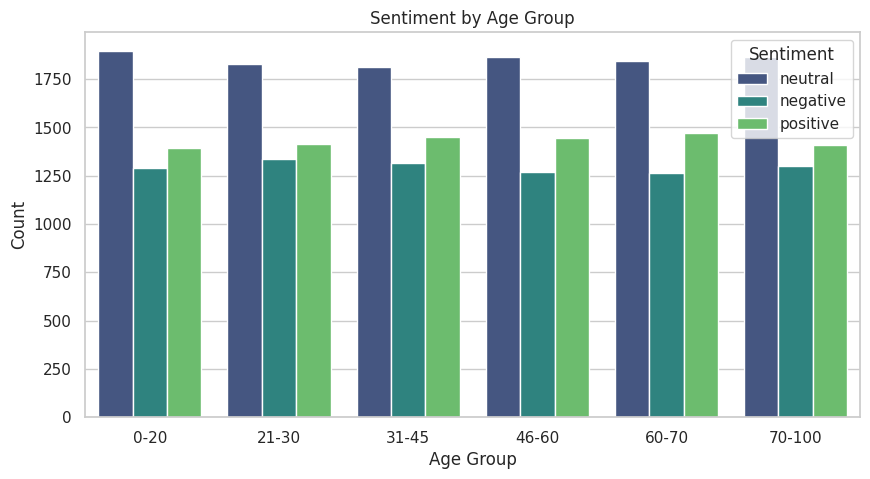

In [10]:
# Sentiment counts by age group
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Age of User', hue='sentiment', palette='viridis', order=sorted(df['Age of User'].unique()))
plt.title('Sentiment by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.show()

## Sentiment by Country (Top 10)

Let's see which countries have the most tweets and their sentiment distribution.

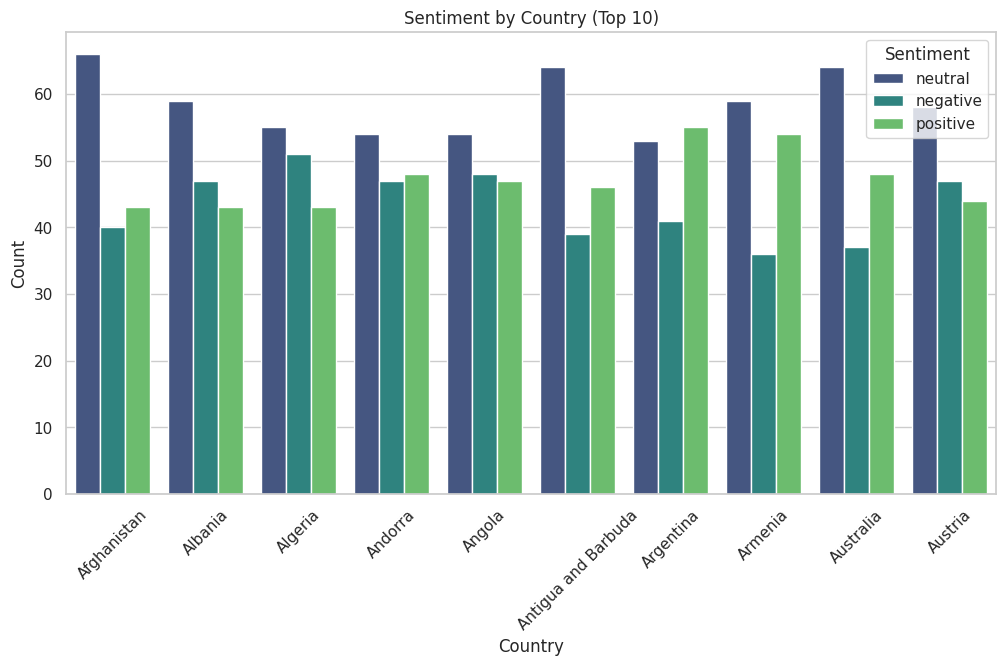

In [11]:
# Top 10 countries by tweet count
top_countries = df['Country'].value_counts().head(10).index
plt.figure(figsize=(12,6))
sns.countplot(data=df[df['Country'].isin(top_countries)], x='Country', hue='sentiment', palette='viridis')
plt.title('Sentiment by Country (Top 10)')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.show()